## 01 - Classification linéaire avec SVM

On revient sur le sujet de la classification, mais avec un nouvel algorithme qui fait un vrai apprentissage pour tenter de généraliser (par opposition à KNN qui mémorise les exemples).

On va apprendre les paramètres d'une droite qui sépare deux classes dans un espace.

In [ ]:
#@title Importations
import numpy as np
import pandas as pd
import plotly.express as px

On va commencer avec des données fictives. Supposons qu'on cherche à prédire le programme d'études d'une personne parmi deux catégories :

- La personne est en *Arts, lettres et communication*
- La personne est en *Sciences de la Nature*

&nbsp;

On possède deux informations au sujet de chaque personne :

- Son amour du théâtre  (valeur entre 0 et 1, 0.0 = déteste et 1.0 = adore)
- Son amour du café (entre 0 et 1 aussi)

In [ ]:
#@title Générer des données fictives
from sklearn.datasets import make_blobs

def generer_donnees(n_samples, random_state=50):
  X, y = make_blobs(n_samples=n_samples, centers=2, n_features=2,
                    cluster_std=1.2,
                    random_state=random_state)
  X = np.round(np.clip(X + 10, 0, 15)/15, 4)
  y = np.array(['SN' if programme else 'Arts' for programme in y])

  # Toutes les données
  df = pd.concat([
      pd.DataFrame(X, columns=['amour_du_theatre', 'amour_du_cafe']),
      pd.DataFrame({"programme": y})
  ], axis="columns")

  return df

In [ ]:
#@title Jeu de données fictif
df = generer_donnees(300)

# Préparer les données
# On mélange le jeu de données, puis on sépare en trois ensembles entraînement/validation/test
df = df.sample(frac=1, random_state=60)

df_entrainement = df.iloc[:180]
df_validation = df.iloc[180:240]
df_test = df.iloc[240:]

# On va commencer par regarder seulement nos données d'entraînement
display(df_entrainement)

,amour_du_theatre,amour_du_cafe,programme
290,0.4217,0.5589,SN
33,0.4330,0.5297,SN
135,0.7291,0.3640,Arts
223,0.6626,0.2870,Arts
292,0.6274,0.2597,Arts
...,...,...,...
136,0.3405,0.5595,SN
2,0.6402,0.3367,Arts
107,0.6253,0.2944,Arts
202,0.5406,0.5219,SN


Seulement regarder l'amour du café ou l'amour du théâtre n'est pas suffisant pour déterminer la classe, il y a une ambiguité sur certaines valeurs :

In [ ]:
display(px.scatter(df_entrainement, x="amour_du_theatre", y="programme", color="programme", title="Amour du théâtre par programme: ambiguité entre 7 et 8", range_x=[0, 1]))
display(px.scatter(df_entrainement, x="amour_du_cafe", y="programme", color="programme", title="Amour du café par programme: ambiguité entre 5 et 7.5", range_x=[0, 1]))

On peut cependant regarder les deux dimensions en même temps et voir que les deux classes sont en réalité bien isolées l'une de l'autre :

In [ ]:
px.scatter(df_entrainement,
           x="amour_du_cafe", y="amour_du_theatre",
           color="programme",
           hover_name=df_entrainement.index,
           title="Nuage de points en 2D : pas d'ambiguité ici, les programmes sont clairement séparés",
           range_x=[0, 1], range_y=[0, 1])

On peut clairement séparer ces deux classes **en traçant une droite** dans le graphique en 2D.

Comme pour la régression linéaire, l'**apprentissage** qu'on peut faire ici va viser à apprendre les **paramètres** de cette droite.

On aurait alors une façon de deviner le programme : selon si on est d'un côté ou de l'autre de la droite, on peut prédire le programme de la personne.

On pourrait utiliser une droite définie avec :

$$y = mx + b$$

Les points $(x, y)$ qui font partie de la droite sont donc tous ceux pour lesquels :

$$0 = mx + -y + b$$

Quand est un point n'est pas sur la droite, il est soit au-dessus, soit en-dessous, à une certaine distance.

&nbsp;

On pourrait considérer la distance entre un nouveau point $(x, y)$ et notre droite, en utilisant une formule de **distance signée**, qui serait soit négative, soit positive, selon si on est au-dessus ou en-dessous de la droite.



\begin{equation}
     \text{Programme} = \begin{cases}
       \text{SN} &\text{si signe(distanceAvecSigne(point, droite)} = +1 \\
       \text{Arts} &\text{si signe(distanceAvecSigne(point, droite)} = -1 \\
     \end{cases}
\end{equation}

<!--
Pour un nouveau point $(x, y)$, on peut insérer ces valeurs dans notre formule et regarder si c'est plus grand ou plus petit que zéro (on regarde le **signe**) :


On aura une distance négative pour l'une des deux classes et une distance positive pour l'autre.

&nbsp;

> *Petite note mathématique* : l'équation $y = mx + b$ n'est pas tout à fait correcte . C'est une équation pour une **fonction** : elle nous limite à avoir **un seul $y$ pour un certain $x$ donné**.
>
> Or, dans le contexte de séparer les deux classes, une droite pourrait très bien être *verticale* (infinité de $y$ pour un même $x$). La bonne façon de faire pour couvrir tous les cas est d'exprimer notre droite d'une autre façon, par exemple :
>
> $$m_1 x + m_2 y + b = 0$$

In [ ]:
def distance_point_droite_signee(point_x, point_y, droite_m, droite_b):
  a = droite_m
  b = -1
  c = droite_b
  return (a*point_x + b*point_y + c) / np.sqrt(a**2 + b**2)

def calculer_nb_erreurs(df_entrainement, droite_m, droite_b):
  nb_erreurs = 0
  for i, point in df_entrainement.iterrows():
    dist = distance_point_droite_signee(
        point.amour_du_cafe, point.amour_du_theatre,
        droite_m, droite_b)

    correct = (dist <= 0) == (point.programme == 'SN')

    nb_erreurs += correct
  return nb_erreurs

In [ ]:
from ipywidgets import interact
import matplotlib.pyplot as plt

def points_sur_droite(m, b, xmin=0, xmax=1):
  x = np.linspace(xmin, xmax, 100)
  y = m * x + b
  return x, y #x.reshape(-1, 1), y.reshape(-1, 1)], axis=1)

def afficher_droites(df, parametres_droites, titre=None):
  for m, b in parametres_droites:
    x, y = points_sur_droite(m, b, 0, 1)

    plt.plot(x, y)

  plt.scatter(df[df.programme == "Arts"].amour_du_cafe,
              df[df.programme == "Arts"].amour_du_theatre,
              c="red")
  plt.scatter(df[df.programme == "SN"].amour_du_cafe,
              df[df.programme =="SN"].amour_du_theatre,
              c="blue")

  plt.xlim(0, 1)
  plt.ylim(0, 1)
  if titre:
    plt.title(titre)
  plt.show()

def afficher_droite_interactive(m, b=0):
  erreurs = calculer_nb_erreurs(df_entrainement, m, b)
  titre = f"Nombre d'erreurs: {erreurs}"

  afficher_droites(df_entrainement, [(m, b)], titre)


out = interact(afficher_droite_interactive,
               m=(0.2,5.0, 0.01),
               b =(-1, 1, 0.0001),
)

interactive(children=(FloatSlider(value=2.6, description='m', max=5.0, min=0.2, step=0.01), FloatSlider(value=…

Ce n'est pas trop dur en jouant avec le widget de trouver une droite qui sépare bien les deux classes.

On va même vite se rendre compte que **plusieurs droites différentes** vont fonctionner avec ces données. Par exemple, testez :

- m = 1.42,  b = -0.065
- m = 1.17, b =  0.0043
- m = 0.3, b =  0.387
- m = 2,  b = -0.3333
- m = 2.82,  b = -0.666
- m = 1.008, b =  0.0668


Quelle est **la** meilleure droite parmi ces choix? On a beaucoup d'options...

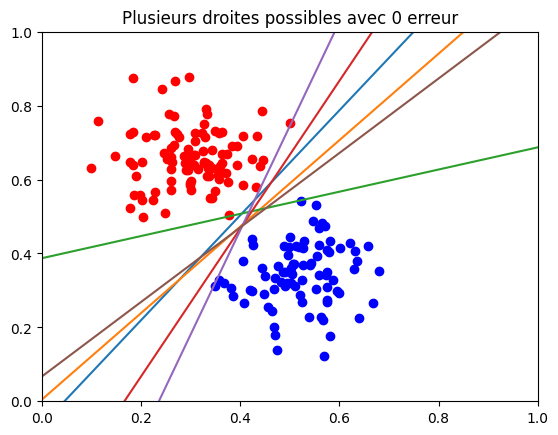

In [ ]:
droites_possibles = [
    # m      b
    (1.42, -0.065),
    (1.17, 0.0043),
    (0.3, 0.387),
    (2, -0.3333),
    (2.82, -0.666),
    (1.008, 0.0668),
]

afficher_droites(df_entrainement, droites_possibles, "Plusieurs droites possibles avec 0 erreur")

Toutes ces droites peuvent séparer complètement les deux classes.

Il faut cependant se souvenir qu'on travaille avec des jeux de données qui ne sont pas exhaustifs. Notre objectif est de généraliser le mieux possible à partir des quelques données qu'on connaît.

L'une de ces droites sera meilleure que les autres en pratique, quand on va la tester sur des nouvelles données.

&nbsp;

Comparons le nombre d'erreurs de classification fait par ces différentes droites avec des nouvelles données jamais vues avant :

Droite #0: 53 erreurs
Droite #1: 40 erreurs
Droite #2: 44 erreurs
Droite #3: 51 erreurs
Droite #4: 74 erreurs
Droite #5: 100 erreurs


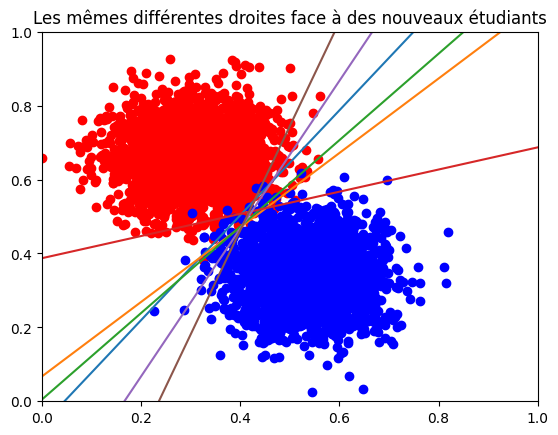

In [ ]:
#@title Simulation: performance de la droite sur des nouvelles personnes
nouvelles_donnees = generer_donnees(5_000)

droites_possibles = [
    (1.42, -0.065),
    (1.008, 0.0668),
    (1.17, 0.0043),
    (0.3, 0.387),
    (2, -0.3333),
    (2.82, -0.666),
]

for i, (m, b) in enumerate(droites_possibles):
  print(f"Droite #{i}:", calculer_nb_erreurs(nouvelles_donnees, m, b), "erreurs")

afficher_droites(
    nouvelles_donnees, droites_possibles,
    "Les mêmes différentes droites face à des nouveaux étudiants"
)

## Algorithme **SVM** : Machine à Vecteur de Support (*Support Vector Machine*)

Une idée pour nous aider à choisir la meilleure droite est de chercher à avoir **un maximum de marge entre la droite et les points de chaque côté**. Plus il y a d'espace entre la droite et les points connus, plus la droite a de chances de bien séparer les nouveaux points qu'on lui présente.

L'algorithme **SVM** tente de trouver cette droite, celle avec le plus de marge possible.

&nbsp;

Cette marge est calculée en cherchant *deux droites parallèles* qui seront "accotées" sur les deux ensembles de points, comme ceci :

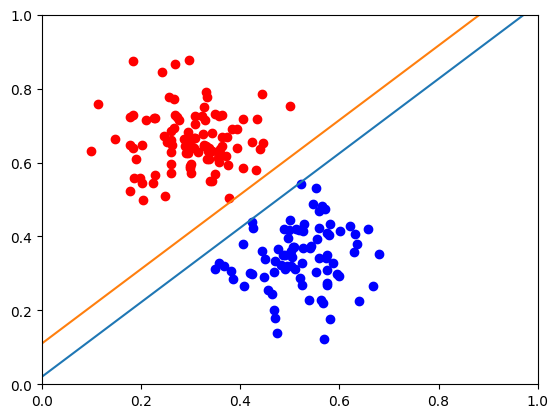

In [ ]:
afficher_droites(df_entrainement, [
  (1.008, 0.02),
  (1.008, 0.11),
])

On a deux droites : une collée sur un ou quelques points rouges, une autre collée sur un ou quelques points bleus.

Les quelques points touchés par ces deux droites sont appelés les **vecteurs de support**.

La paire de droites parallèles qui sont le plus loin l'une de l'autre définit la marge maximale qu'on peut avoir pour séparer les deux classes.

La droite finale qu'on va utiliser pour la classification est celle à mi-chemin entre les deux (*ie*, une droite avec la même pente que les deux droites parallèles, mais avec la moyenne des deux $b$ trouvés) :

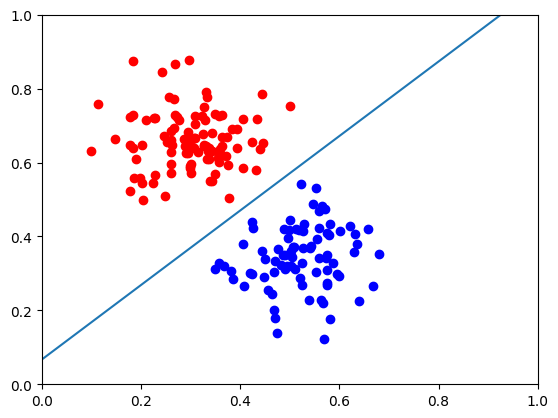

In [ ]:
afficher_droites(df_entrainement, [
  (1.008, 0.0668),
])

Cet algorithme est formulé comme une optimisation mathématique. La classe à prédire $y_i$ devra être soit -1, soit +1. C'est le signe (positif ou négatif) qui va déterminer la classe.

&nbsp;

L'optimisation à faire est :

\begin{align}
\text{maximiser }~~~~ &\text{distance entre les deux droites} \\
\text{sujet à}~~~~ & y_{i~predit} \text{  est de meme signe que  } y_i \text{   pour tous les } i \\
\end{align}

$y_{i~predit}$ est la distance signée à la droite finale.

## LinearSVC dans scikit-learn

Vous devriez commencer à savoir comment les différents algos de scikit-learn fonctionnent.

Le modèle le plus simple qui implémente l'algorithme SVM s'appelle `LinearSVC` (c'est un **SV**M **C**lassifier linéaire).

&nbsp;

Entraînez un `LinearSVC` sur les données présentées plus haut. Affichez ensuite :

- L'exactitude obtenue sur l'ensemble de validation.
- Le nombre de mauvaises classifications (le nombre de fois que la prédiction est incorrecte) sur l'ensemble de validation

Rappel : ne touchez pas à l'ensemble de test, on devrait uniquement s'en servir à la toute fin, une fois qu'on est certains du modèle qui nous intéresse.

In [ ]:
#@title Importations
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [ ]:
#@title Exercice 1.1
X_entrainement = df_entrainement[['amour_du_cafe', 'amour_du_theatre']]
y_entrainement = df_entrainement['programme']

X_validation = df_validation[['amour_du_cafe', 'amour_du_theatre']]
y_validation = df_validation['programme']

X_test = df_test[['amour_du_cafe', 'amour_du_theatre']]
y_test = df_test['programme']

modele = ...

#####################

modele = LinearSVC()

modele.fit(X_entrainement, y_entrainement)

y_predictions = modele.predict(X_validation)

print((y_validation != y_predictions).sum(), "mauvaises classifications")
print("Exactitude =", accuracy_score(y_validation, y_predictions))

1 mauvaises classifications
Exactitude = 0.9833333333333333


Une fois votre modèle entraîné, vous pouvez afficher la droite résultante en exécutant la cellule suivante :

Droite apprise: y =  0.8008362694126129 x +  0.1652861429466203


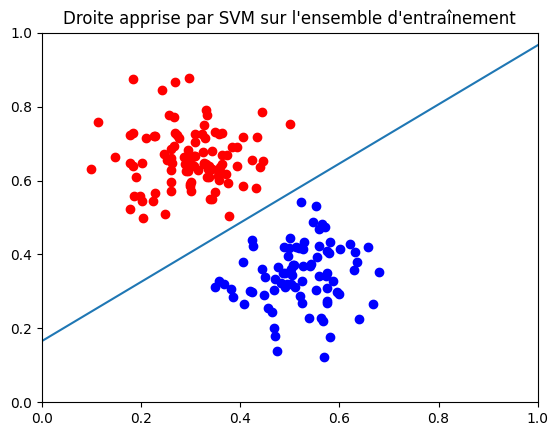

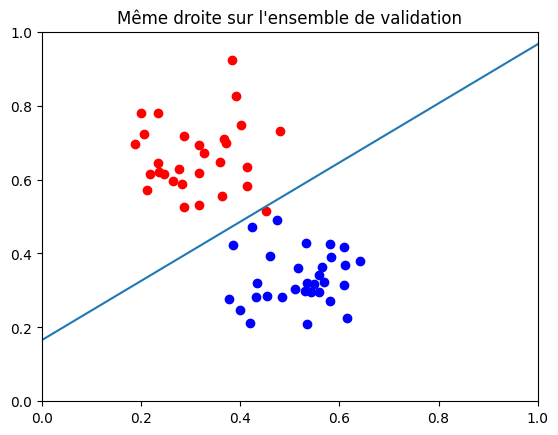

In [ ]:
#@title Fonction de apprise

# LinearSVM utilise la formulation m1 x + m2 y + b = 0
# Dans la mesure où la droite n'est pas verticale, on peut isoler y
# et réexprimer ça comme une fonction: y = -m1 / m2 x - b / m2
m1, m2 = -modele.coef_[0]
b = modele.intercept_[0]

print("Droite apprise: y = ", -m1/m2, "x + ", b/m2)

afficher_droites(X_entrainement.assign(programme=y_entrainement), [(-m1/m2, b/m2)], "Droite apprise par SVM sur l'ensemble d'entraînement")

afficher_droites(df_validation, [(-m1/m2, b/m2)], "Même droite sur l'ensemble de validation")

## Et si les données ne sont pas séparables avec une seule droite?

Notre faux jeu de données était très joli : deux petits groupes faciles à séparer avec une droite.

Cependant, rien ne nous garanti dans la vraie vie qu'on va toujours avoir des groupes de points séparables par une droite.

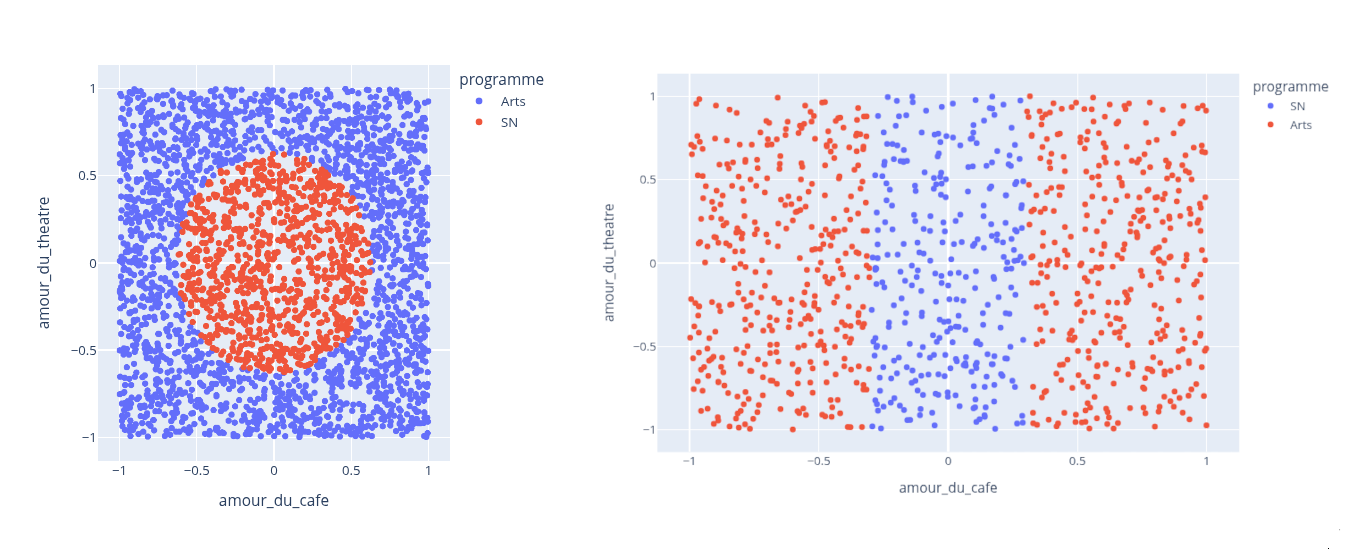

On a quand même des options dans ces cas-là.

### Options 1: Transformer les données pour les rendre séparables

On peut réutiliser la même astuce que pour la régression linéaire : trouver une droite qui marche bien pour une version transformée des données.

Peut-être qu'aucune droite ne permet de séparer directement les $(x_i, y_i)$, mais qu'en regardant plutôt des $(x_i^2, y_i)$, ça change les choses.

Par exemple, si on avait le jeu de données suivant :

In [ ]:
from sklearn.datasets import make_blobs

X = np.random.random((1000, 2)) * 2 - 1
y = ['SN' if x else 'Arts' for x in (np.abs(X[:, 1]) < 0.3)]

# Toutes les données
df_non_separable = pd.concat([
    pd.DataFrame(X, columns=['amour_du_theatre', 'amour_du_cafe']),
    pd.DataFrame({"programme": y})
], axis="columns")

px.scatter(df_non_separable, x="amour_du_cafe", y="amour_du_theatre", color="programme", width=500, height=500)


On ne peut pas facilement trouver une seule droite qui sépare les points rouges des points bleus.

On peut cependant mettre tous les $x_i$ au carré, ce qui nous donnerait :

In [ ]:
df_carre = df_non_separable.assign(
  amour_du_cafe_carre=df_non_separable.amour_du_cafe**2,
)
px.scatter(df_carre, x="amour_du_cafe_carre", y="amour_du_theatre", color="programme", width=500, height=500)


Les points rouges qui étaient à gauche (négatifs) et à droite (positifs) se retrouvent tous à droite après la mise au carré.

Dans cette nouvelle version, on peut facilement tracer une droite verticale qui sépare nos deux classes.

Ce truc peut être utilisé dans plusieurs contextes.

Un autre exemple où les points ne peuvent pas être séparés par une seule droite :

In [ ]:
from sklearn.datasets import make_blobs

np.random.seed(1337)
X = np.random.random((3000, 2)) * 2 - 1
y = (X**2).sum(axis=-1) < 0.4
y = ['SN' if y_i else 'Arts' for y_i in y]

# Toutes les données
df_non_separable_cercle = pd.concat([
    pd.DataFrame(X, columns=['amour_du_theatre', 'amour_du_cafe']),
    pd.DataFrame({"programme": y})
], axis="columns")

px.scatter(df_non_separable_cercle,
           x="amour_du_cafe", y="amour_du_theatre", color="programme",
           width=500, height=500)

Encore une fois à première vue, la classification avec une seule droite n'est pas suffisante.

On peut cependant transformer ces données et utiliser la distance entre chaque point et $(0, 0)$ :

In [ ]:
df_non_separable_cercle = df_non_separable_cercle.assign(amour_du_cafe_carre=df_non_separable_cercle.amour_du_cafe**2)

distance_au_centre = np.sqrt(df_non_separable_cercle.amour_du_cafe**2 + df_non_separable_cercle.amour_du_theatre**2)

df_non_separable_cercle = df_non_separable_cercle.assign(distance_au_centre=distance_au_centre)

px.scatter(df_non_separable_cercle,
              y="amour_du_theatre",
              x="distance_au_centre", color="programme")

In [ ]:
#@title Exercice 1.2 : tentez de rendre le jeu de données suivant séparable avec une droite
from sklearn.datasets import make_blobs

np.random.seed(1337)
X = np.random.random((3000, 2)) * 2 - 1
y = np.logical_or((X**2).sum(axis=-1) > 0.7, (X**2).sum(axis=-1) < 0.2)
y = ['SN' if y_i else 'Arts' for y_i in y]

# Jeu de données à utiliser pour l'exercice
df_exercice = pd.concat([
    pd.DataFrame(X, columns=['amour_du_theatre', 'amour_du_cafe']),
    pd.DataFrame({"programme": y})
], axis="columns")

display(px.scatter(df_exercice,
           x="amour_du_theatre", y="amour_du_cafe", color="programme",
           width=500, height=500))

##########

# Calcule la distance de chaque point au centre (0, 0)
distance_au_centre = np.sqrt(df_exercice.amour_du_cafe**2 + df_exercice.amour_du_theatre**2)
df_exercice = df_exercice.assign(distance_au_centre=distance_au_centre)

display(px.scatter(df_exercice,
           x="amour_du_theatre", y="distance_au_centre", color="programme",
           width=500, height=500))

# Recentre la valeur de distance_au_centre en (0, 0), de façon à avoir la moitié dans les négatifs et la moitié dans les positifs
etendue_distance_arts = df_exercice[df_exercice.programme == 'Arts'].distance_au_centre.max() - df_exercice[df_exercice.programme == 'Arts'].distance_au_centre.min()
centre_arts = etendue_distance_arts / 2 + df_exercice[df_exercice.programme == 'Arts'].distance_au_centre.min()

df_exercice = df_exercice.assign(distance_au_centre=df_exercice.distance_au_centre - centre_arts)

display(px.scatter(df_exercice,
           x="amour_du_theatre", y="distance_au_centre", color="programme",
           width=500, height=500))

# Mettre au carré pour transformer les négatifs en positifs
df_exercice = df_exercice.assign(distance_au_centre=df_exercice.distance_au_centre**2)

display(px.scatter(df_exercice,
           x="amour_du_theatre", y="distance_au_centre", color="programme",
           width=500, height=500))

## Option 2: Utiliser une **marge souple**, faire un compromis entre la marge et la séparation parfaite des classes

Un exemple un peu moins simple est celui où les groupes sont partiellement entre-mêlés :

In [ ]:
df = generer_donnees(3000, random_state=2858)
df = df.sample(frac=1, random_state=60)

df_entrainement = df.iloc[:2000]
df_validation = df.iloc[1800:2400]
df_test = df.iloc[2400:]

# On va commencer par regarder seulement nos données d'entraînement
px.scatter(df_entrainement, x="amour_du_cafe", y="amour_du_theatre", color="programme")

Il y a une part d'ambiguité dans ces données, et c'est ce qu'on aura la majorité du temps dans le vrai monde : en vrai, on ne peut probablement pas s'attendre à ce que connaître l'amour du théâtre et l'amour du café soit suffisant pour prédire 100% du temps le programme d'études d'une personne.

Ça va probablement nous donner des indices, mais pas 100% de bonnes réponses.

Aucune droite ne peut séparer parfaitement les deux classes ici, mais ça ne veut pas dire qu'il n'y a rien à faire. On peut quand même chercher quelle droite fonctionnerait avec le plus de points possible.

&nbsp;

L'algorithme SVM peut être adapté pour utiliser une **marge souple** : plutôt que de chercher une droite qui classe tous les points correctement, on accepte d'avoir un peu de mauvaises classifications ou encore un petit nombre de points à l'intérieur de ce qui est défini comme la marge.

On va chercher à faire **compromis entre la meilleure droite (marge maximale) et une petite quantité de points mal classés ou gardés trop proches de la droite**.

Un **hyperparamètre $C$**, avec une valeur $C > 0$, va contrôler ce compromis. Plus $C$ est élevé, moins le SVM est tolérant aux mauvaises classifications en cherchant sa droite de séparation.

&nbsp;

La contrainte de devoir séparer parfaitement tous les points est retirée. La minimisation mathématique à faire est modifiée :

\begin{align}
\text{minimiser }~ &\frac{1}{\text{distance entre les deux droites}} + C ( ~ \frac{1}{N} \sum_i^N \text{penalite}(x_i) ~) \\
\\
\text{penalite}(x_i) &= \begin{cases}
       \text{0} &\text{si le point } x_i \text{ est bien classé et hors de la marge} \\
       \text{un nombre reel positif} &\text{si } x_i \text{ est mal classé ou dans la marge}\\
     \end{cases}
\end{align}

&nbsp;

*Notez : Maximiser la marge est équivalent à minimiser son l'inverse ici.*

&nbsp;

Plus précisément, la formule utilisée pour calculer cette pénalité se nomme la *hinge loss* :

$$\text{hinge}(y_i, \hat{y}_i) = \max\left\{1 - \hat{y}_i y_i, 0\right\}$$

<!--
&nbsp;

La *marge* dans ce contexte est définie comme étant l'ensemble des points à une distance inférieure à 1 de la droite de classification. (Normalement avec SVM, on doit faire une **mise à l'échelle des données** pour les ramener entre 0 et 1). -->

<!-- &nbsp;

La minimisation mathématique à faire est ajustée :

minimiser 1/(distance entre les deux droites) + C * (pénalité appliquée à tous les points mal classés, proportionnelle à )
sans la contrainte de devoir séparer parfaitement tous les points

$${\displaystyle \lVert \mathbf {w} \rVert ^{2}+C\left[{\frac {1}{n}}\sum _{i=1}^{n}\max \left(0,1-y_{i}(\mathbf {w} ^{\mathsf {T}}\mathbf {x} _{i}-b)\right)\right],}$$

$$\text{minimiser} {\displaystyle \left[{\frac {1}{n}}\sum _{i=1}^{n}\max \left(0,1-y_{i}(\mathbf {w} ^{\mathsf {T}}\mathbf {x} -b)\right)\right]+\lambda \|\mathbf {w} \|^{2}.}$$

avg max(0, 1 - reponse * distance_signee_droite) + lambda ||w||^2

&nbsp; -->

**Exercice de révision** : rappelez la différence entre un *paramètre* et un *hyperparamètre*

**RÉPONSE**

Un paramètre est appris à partir des données.

Un hyperparamètre doit être spécifié au moment de créer le modèle, avant même de lui avoir fourni des années. La façon de trouver la meilleure valeur d'un hyperparamètre est d'en tester plein et d'évaluer le résultat sur l'ensemble de validation.

**Exercice 1.3**

Je vous fournis un autre jeu de données qui ne peuvent pas être séparées parfaitement.

Cherchez quelle valeur de $C$ donne la meilleure droite.

Testez plusieurs valeurs de $C$ différentes dans une boucle `for`.

In [ ]:
#@title Exercice 1.3 : Chercher le meilleur hyperparamètre C

# Jeu de données conçu pour être imparfait
df_melange = generer_donnees(3000, random_state=2858)
df_melange = df_melange.sample(frac=1, random_state=60)
np.random.seed(1337)
df_melange.loc[5*df_melange.amour_du_cafe**2 + (df_melange.amour_du_theatre)**2 < np.random.random(len(df_melange)) * 0.2 + 0.4, "programme"] = 'Arts'
df_melange.loc[df_melange.amour_du_cafe > 0.2, "programme"] = 'SN'
idx = df_melange.index.copy()
np.random.shuffle(np.array(idx))
idx = idx[:500]
df_melange.loc[idx, "programme"] = 'Arts'

df_entrainement = df_melange.iloc[:2000]
df_validation = df_melange.iloc[1800:2400]
df_test = df_melange.iloc[2400:]

display(px.scatter(df_entrainement, x="amour_du_cafe", y="amour_du_theatre", color="programme"))

X_entrainement = df_entrainement.drop('programme', axis='columns')
y_entrainement = df_entrainement['programme']
X_validation = df_validation.drop('programme', axis='columns')
y_validation = df_validation['programme']
X_test = df_test.drop('programme', axis='columns')
y_test = df_test['programme']

######################

# Idée de démarche: noter les paramètres + résultats dans un tableau
# qui sera transformé en DataFrame pour faire des visualisations

resultats = []
for C in np.arange(0.01, 25, 0.01):
  modele = LinearSVC(C=C)

  modele.fit(X_entrainement, y_entrainement)

  y_predictions = modele.predict(X_validation)

  resultats.append([
      C,
      (y_validation != y_predictions).sum(),
      accuracy_score(y_validation, y_predictions)
  ])

# DataFrame à partir des résultats
df_resultats = pd.DataFrame(resultats, columns=['C', 'nb_mauvais', 'exactitude'])
print(df_resultats.nb_mauvais.max() - df_resultats.nb_mauvais.min())

# Graphique de l'exactitude en fonction de C
display(px.scatter(df_resultats, "C", "exactitude"))

# On pourra également fouiller dans le DataFrame
display(df_resultats)

69


,C,nb_mauvais,exactitude
0,0.01,139,0.768333
1,0.02,139,0.768333
2,0.03,139,0.768333
3,0.04,139,0.768333
4,0.05,135,0.775000
...,...,...,...
2494,24.95,71,0.881667
2495,24.96,71,0.881667
2496,24.97,71,0.881667
2497,24.98,71,0.881667


## Hyperparamètre $C$ et Régularisation

La **régularisation** est l'idée de **rendre notre modèle moins performant** sur les données d'entraînement, dans le but de lui permettre de **mieux généraliser à des nouveaux exemples**.

&nbsp;

L'hyperparamètre $C$ peut être vu comme **une régularisation** du modèle.

De base, tel que je vous l'ai présenté, l'algorithme SVM cherche à avoir une droite qui sépare parfaitement les deux classes.

On a déjà vu dans les derniers modules que parfois, chercher à atteindre la perfection dans nos données d'entraînement, ça mène à du **surapprentissage**. Moins bien apprendre les données d'entraînement, ça va souvent être nécessaire pour généraliser correctement.

Si on avait eu dans notre jeu de données fictif un point un peu bizarre, comme ceci :

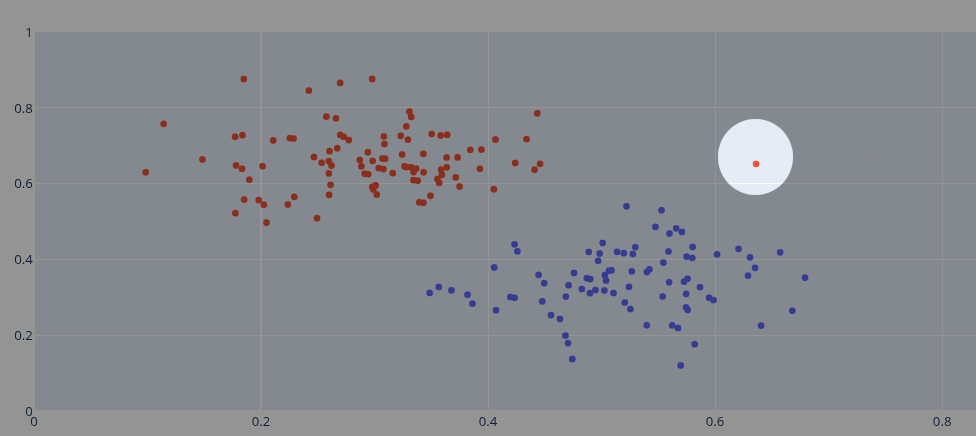

Tenter de trouver une droite qui sépare **parfaitement** les points rouges des points bleus nous aurait mené à la droite :

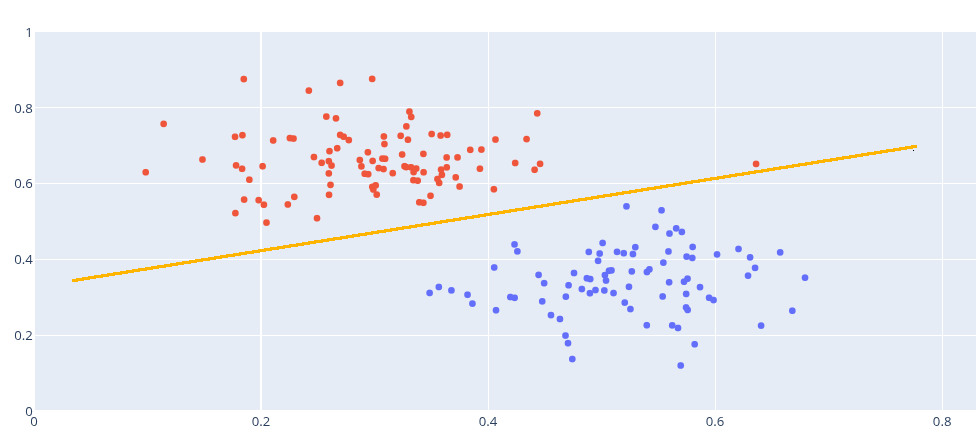

Qui laisse beaucoup moins de marge entre les deux classes...

Si on avait accepté de faire une erreur sur cet unique point bizarre, on aurait retrouvé une droite similaire à tout à l'heure :

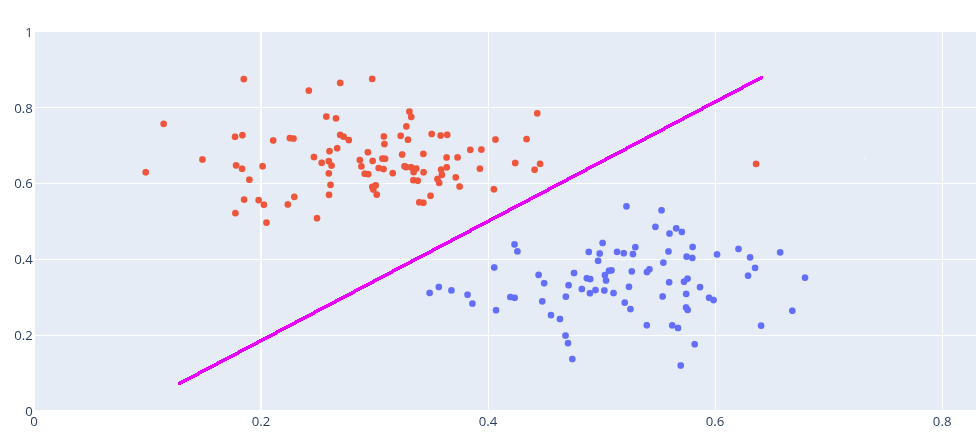

qui est un meilleur choix en termes de généralisation à des exemples futurs.

## SVM en plusieurs dimensions

Jusqu'ici, on a seulement considéré séparer des points 2D avec une droite, mais on peut appliquer la même idée en 3D ou en plusieurs dimensions.

Un peu comme pour la régression linéaire :

- En 2D, on sépare des classes avec **une droite**
- L'équation équivalente à celle d'une droite pour le cas des points en 3D est l'équation d'**un plan**
- En plus de dimensions que ça, on parle d'un **hyperplan** (bonne chance pour dessiner ça)

Gardez en tête que dans tous les cas, on peut voir une droite/un plan/un hyperplan comme étant simplement une **somme pondérée** des valeurs d'entrée.

In [ ]:
#@title Démo : SVM en plusieurs dimensions
def generer_donnees_3d(n_samples, random_state=50):
  X, y = make_blobs(n_samples=n_samples, centers=2, n_features=3,
                    cluster_std=1.4,
                    random_state=random_state)
  X = np.round(np.clip(X + 10, 0, 15)/15, 4)
  y = np.array(['SN' if programme else 'Arts' for programme in y])

  # Toutes les données
  df = pd.concat([
      pd.DataFrame(X, columns=['amour_du_theatre', 'amour_du_cafe', 'amour_du_cinema' ]),
      pd.DataFrame({"programme": y})
  ], axis="columns")

  return df

df_3d = generer_donnees_3d(300, 0)

modele_pour_visualisation3d = LinearSVC()
modele_pour_visualisation3d.fit(df_3d.drop('programme', axis='columns'), df_3d.programme)

# -m1/m3 amour_du_theatre + -m2/m3 cafe + -b/m3 = cinema
m1, m2, m3 = modele_pour_visualisation3d.coef_[0]
b = modele_pour_visualisation3d.intercept_[0]

def point_sur_plan(theatre, cafe):
  return -m1/m3 * theatre + -m2/m3 * cafe + -b/m3

plan_de_separation = []
for amour_du_theatre in np.linspace(0, 1, 25):
  for amour_du_cafe in np.linspace(0, 1, 80):
    amour_du_cinema = point_sur_plan(amour_du_theatre, amour_du_cafe)
    if 0.2 <= amour_du_cinema <= 1.2: # Plus belle visualisation quand on restreint à ça
      plan_de_separation.append([
          amour_du_theatre,
          amour_du_cafe,
          amour_du_cinema,
      ])

plan_de_separation = pd.DataFrame(plan_de_separation, columns=['amour_du_theatre', 'amour_du_cafe', 'amour_du_cinema'])
fig1 = px.scatter_3d(
  df_3d,
  x='amour_du_theatre', y='amour_du_cafe', z='amour_du_cinema',
  color='programme',
)
fig2 = px.scatter_3d(
  plan_de_separation,
  x='amour_du_theatre', y='amour_du_cafe', z='amour_du_cinema',
  opacity=0.3, color_discrete_sequence=['orange'],
)

from plotly.graph_objects import Figure
fig = Figure(data=fig1.data + fig2.data)
fig.update_layout(dict(
    title="Plan 2D qui sépare les deux classes affichées en 3D",
    scene=dict(
      xaxis_title='amour_du_theatre',
      yaxis_title='amour_du_cafe',
      zaxis_title='amour_du_cinema',
    ),
))
display(fig)

## Mise à l'échelle des données

On a parlé de mettre les données à l'échelle pour améliorer les résultats de l'algo KNN.

Fondamentalement, *SVM* utilise la **distance à la droite de classification** pour prédire la classe d'un nouveau point. Pour éviter qu'une caractéristique ne pèse plus dans la formule de distance que les autres, on devrait toujours s'assurer que les caractéristiques des données utilisées dans le SVM ont été mises à l'échelle.

Petit truc supplémentaire pour SVM en particulier : la formulation mathématique présume que les données sont à l'échelle. La marge est définie comme : *l'espace situé à une distance $\le 1$ de la droite*.

Si les données ne sont pas mises à l'échelle, ça va avoir toutes sortes d'impact sur la qualité de la solution trouvée et sur le temps requis pour d'entraînement du modèle.

## En résumé

- On peut apprendre à classifier avec une **droite** (ou un plan, ou un hyperplan/une somme pondérée) qui sépare les points des différentes classes
- L'algorithme **SVM** (*Support Vector Machine*) est une optimisation mathématique qui cherche la droite avec une **marge maximale**
- Quand les points ne peuvent pas être séparés par une droite :
    - On peut **transformer les points** pour qu'ils deviennent séparables
    - On peut utiliser **une marge souple** : faire un **compromis entre des points parfaitement bien classés et un maximum de marge**
- L'**hyperparamètre $C$** permet de contrôler la "souplesse" de la marge : plus $C$ est élevé, plus l'importance est placée sur le fait de bien classer le plus de points possibles
- Puisque SVM utilise la distance point-droite dans sa formulation, la **mise à l'échelle des données** est nécessaire

## 02 - Classification de lunettes

À ce stade-ci, vous devriez commencer à comprendre que l'apprentissage machine est essentiellement un bazooka qu'on peut déployer sur n'importe quel problème, peu importe à quel point il est complexe, pourvu qu'on dispose d'un jeu de données.

Essayons quelque chose : peut-on entraîner un SVM à dire si un dessin de visage porte des lunettes ou non?

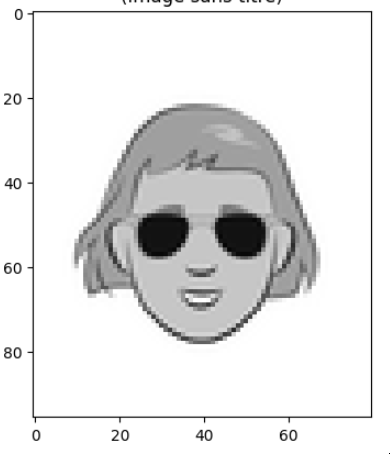

In [ ]:
#@title Importations
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

In [ ]:
#@title Téléchargement des dessins
!(test -e cartoonset10k.pkl && echo "Fichier prêt") || (wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cartoonset10k.pkl.gz -O cartoonset10k.pkl.gz && gunzip "cartoonset10k.pkl.gz")
!(test -e cartoonset10k-metadata.pkl && echo "Fichier prêt") || (wget https://raw.githubusercontent.com/316k/misc-data/refs/heads/main/cartoonset10k-metadata.pkl -O cartoonset10k-metadata.pkl)

Fichier prêt
Fichier prêt


Voici un peu de code qui réorganise les mêmes images qu'au module précédent, qui note :

- `X` = les images entières, écrasées en 1D
- `y` = 1 si le visage a des lunettes, 0 sinon

On a déjà préparé les `X_entrainement`, `y_entrainement`, même chose pour validation et test.

&nbsp;

Le jeu de données a ~50% de visages avec lunettes, et 50% de visages sans lunettes. Autrement dit : **répondre au hasard donnerait 50% d'exactitude**.

Est-ce qu'on peut faire mieux que ça?

In [ ]:
#@title Construction du jeu de données
import pickle
with open("cartoonset10k.pkl", "rb") as f:
    faces = pickle.load(f) # Liste python de matrices numpy
with open("cartoonset10k-metadata.pkl", "rb") as f:
    faces_metadata = pickle.load(f)
HAUTEUR_IMG, LARGEUR_IMG = faces[0].shape
faces = np.array(faces).reshape(10000, -1)
y = faces_metadata.glasses != 11
faces_avec_lunettes = faces[y]
faces_sans_lunettes = faces[~y]

X = np.concat([
    faces_avec_lunettes,
    faces_sans_lunettes
])
y = np.array([1] * len(faces_avec_lunettes) + [0] * len(faces_sans_lunettes)).reshape(-1, 1)

Xy = np.concat([X, y], axis=1)
np.random.seed(1337)
indexes = np.arange(len(Xy))
np.random.shuffle(indexes)
Xy = Xy[indexes]

X_entrainement_brute = Xy[:5000, :-1]
X_validation_brute = Xy[5000:7500, :-1]
X_test_brute = Xy[7500:, :-1]

y_entrainement = Xy[:5000, -1]
y_validation = Xy[5000:7500, -1]
y_test = Xy[7500:, -1]

# Petit bout de code qui met les données à l'échelle (utilise la Cote Z)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_entrainement_brute)

X_entrainement = scaler.transform(X_entrainement_brute)
X_validation = scaler.transform(X_validation_brute)
X_test = scaler.transform(X_test_brute)

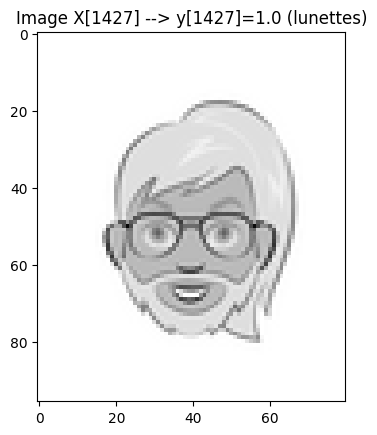

In [ ]:
#@title Visualisation des X[i] et y[i] d'entraînement
import matplotlib.pyplot as plt

def imshow(matrice, titre="(Image sans titre)", subplot=None):
  axis = plt
  if subplot is not None:
    axis = subplot
  matrice = np.clip(matrice, 0, 1)
  axis.imshow(matrice, cmap="gray", vmin=0, vmax=1)
  if subplot is None:
    axis.title(titre)
    axis.show()

def afficher_image(i=0):
  reponse = f"y[{i}]={y_entrainement[i]} " + ("(lunettes)" if y_entrainement[i] else "(pas de lunettes)")
  imshow(X_entrainement_brute[i].reshape(HAUTEUR_IMG, LARGEUR_IMG), f"Image X[{i}] --> {reponse}")

from ipywidgets import interact

output = interact(afficher_image, i=(0, len(X_entrainement_brute)-1))

**Exercice 2.1**

Entraînez différents `LinearSVC()` en utilisant les X et y d'entraînement/validation et comparez les performances.

Testez les valeurs suivantes pour l'hyperparamètre $C$ : 0.01, 0.1, 1, 10

In [72]:
#@title Exercice 2.1 : Entraînez un LinearSVC() à détecter des lunettes dans des dessins de visages
from sklearn.svm import LinearSVC

# Utilisez X_entrainement, y_entrainement et X_validation, y_validation
model = ...

######

# Première vérification sur quelques valeurs éloignées, sur une échelle log
for C in [0.01, 0.1, 1, 10]:
  model = LinearSVC(C=C)

  model.fit(X_entrainement, y_entrainement)

  y_predictions = model.predict(X_validation)

  print("SVC avec C =", C, ":", accuracy_score(y_validation, y_predictions))

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



SVC avec C = 0.01 : 0.9964


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



SVC avec C = 0.1 : 0.9988


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



...

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



SVC avec C = 8.0 : 0.9984


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



SVC avec C = 9.0 : 0.998
SVC avec C = 10.0 : 0.9984


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



**Exercice 2.2**

Choisissez le meilleur hyperparamètre $C$ trouvé au dernier numéro et refaites l'entraînement final + la vérification de l'exactitude sur le jeu de données de test.

Une fois que c'est fait, exécutez la cellule d'après. Elle contient un widget qui va vous permettre de jouer avec votre modèle final pour regarder son comportement.

In [76]:
#@title Exercice 2.2

modele_final = ...

######

MEILLEUR_C = 1

modele_final = LinearSVC(C=MEILLEUR_C)

modele_final.fit(X_entrainement, y_entrainement)

y_predictions_test = modele_final.predict(X_test)

print("Exactitude finale:", accuracy_score(y_test, y_predictions_test))

Exactitude finale: 0.9956


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



Finalement, une fois votre modèle final entraîné, exécutez la cellule suivante pour essayer le modèle sur différentes images du jeu de test :

In [77]:
#@title Visualisation des prédictions pour l'ensemble de test
def afficher_image(i=0):
  prediction = model.predict(X_test[i:i+1])[0]
  prediction = ("Lunettes" if prediction else "Pas de lunettes") +" " + ("✔" if prediction == y_test[i] else "X")
  imshow(X_test_brute[i].reshape(HAUTEUR_IMG, LARGEUR_IMG), f"Prédiction du modèle : {prediction}")

from ipywidgets import interact

output = interact(afficher_image, i=(0, len(X_test)-1))

interactive(children=(IntSlider(value=0, description='i', max=2499), Output()), _dom_classes=('widget-interact…

## Interpréter ce que le SVM fait

Une droite, un plan, ou la formule généralisée en n'importe quel nombre de dimensions, ça correspond toujours à une **somme pondérée** des caractéristiques d'entrée.

Un SVM, ça apprend donc les coefficients d'une somme pondérée, puis ça vérifie si cette somme pondérée est > ou < qu'un certain seuil.

&nbsp;

Dans la représentation des données qu'on a choisi ici, notre SVM donne un coefficient à chaque pixel dans l'image pour en faire une somme pondérée.

On peut visualiser l'importance apprise pour chaque pixel en affichant la valeur absolue des coefficients sous forme d'image :

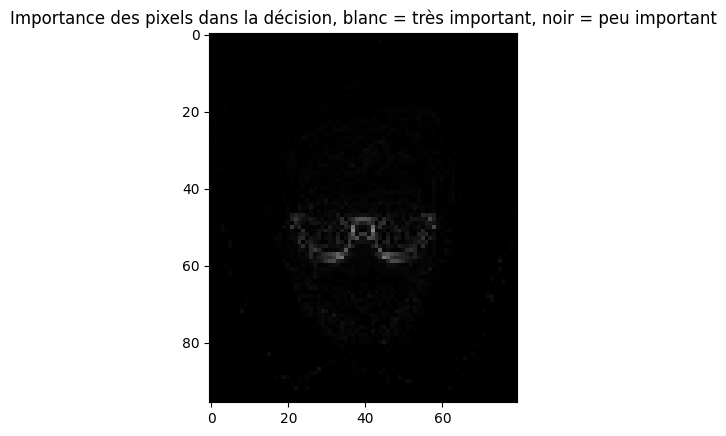

In [78]:
#@title Interprétation des coefficients trouvés
imshow(np.abs(modele_final.coef_.reshape(96, 80)), "Importance des pixels dans la décision, blanc = très important, noir = peu important")